In [1]:
import jax
import jax.numpy as jnp
import mujoco
from mujoco import mjx
import xml.etree.ElementTree as ET
import os
from gnoci_gym.load_xml import _load_and_perturb_basic_xml
from gnoci_gym.sysid.sysid_ds_interface import SysidDSInterface
import optax
import warnings
import time

warnings.filterwarnings("ignore", module="mujoco.mjx._src.mesh")

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [2]:

def build_model(mx, params):
    # learnable_params: frictionloss, damping, kv, kp, armature, actuator_dynprm, filter time constant
    # Note: mx.actuator_biasprm[:, 2] duplicates mx.actuator_biasprm[:, 1], we should pass in a single kv param and then replace both in the model
    # damping, frictionloss, armature, kp should be positive so should learn as log_...
    # kv should be negative so should learn as log_... and then negate when applying.

    log_kp = params['log_kp']
    log_kv = params['log_kv']
    log_tau = params['log_tau']
    log_damping = params['log_damping']
    log_frictionloss = params['log_frictionloss']
    log_armature = params['log_armature']

    kp = jax.nn.softplus(log_kp)
    kv = jax.nn.softplus(log_kv)
    tau = jax.nn.softplus(log_tau)
    damping = jax.nn.softplus(log_damping)
    frictionloss = jax.nn.softplus(log_frictionloss)
    armature = jax.nn.softplus(log_armature)

    mx = mx.tree_replace({
        'actuator_gainprm': mx.actuator_gainprm.at[:, 0].set(kp),
        'actuator_biasprm': mx.actuator_biasprm.at[:, 1].set(-kp).at[:, 2].set(-kv),
        'actuator_dynprm':  mx.actuator_dynprm.at[:, 0].set(tau),
        'dof_damping':      damping,
        'dof_frictionloss': frictionloss,
        'dof_armature':     armature,
    })
    return mx

def extract_joint_obs():
    joint_pos = self.data.sensordata[self.joint_pos_sensor_addrs] / np.pi


def rollout(params, mx, q0, qd0, actions, n_substeps):
    mx_ = build_model(mx, params)
    data = mjx.make_data(mx_)
    data = jax.vmap(lambda q, qd: data.tree_replace({"qpos": q, "qvel": qd}), (0, 0))(q0, qd0)

    def substep(data, _):
        data = jax.vmap(mjx.step, (None, 0))(mx_, data)
        return data, None

    def step_fn(data, action):
        data = data.tree_replace({"ctrl": action})
        # n_substeps physics steps per control action
        data, _ = jax.lax.scan(substep, data, xs=None, length=n_substeps)
        return data, (data.qpos, data.qvel)

    actions_t = jnp.moveaxis(actions, 1, 0) # (B, T, A) -> (T, B, A)
    final_data, (q_traj, qd_traj) = jax.lax.scan(step_fn, data, actions_t)
    # Note that becuase there are 2n actions per n states the resulting trajectories are 
    # 2n + 1 long, we need to remove the first state and take every other state after that.
    q_traj = jnp.moveaxis(q_traj[::2], 0, 1)
    qd_traj = jnp.moveaxis(qd_traj[::2], 0, 1)
    return q_traj, qd_traj


def loss(params, mx, q_targ, q0, qd0, actions, motor_idxs):
    q_traj, _ = rollout(params, mx, q0, qd0, actions, 5)
    return jnp.mean((q_targ[:, :, motor_idxs] - q_traj[:, :, motor_idxs])**2)


grad_fn = jax.value_and_grad(loss)


def make_train_step(optimizer):
    @jax.jit
    def train_step(params, opt_state, mx, q_targ, q0, qd0, actions, motor_idxs):
        loss_val, grads = grad_fn(params, mx, q_targ, q0, qd0, actions, motor_idxs)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_val
    return train_step


In [ ]:
ds = SysidDSInterface()

xml = _load_and_perturb_basic_xml('scene', fix_root_body=True, strip_contact_sensors=True)
model = mujoco.MjModel.from_xml_string(xml)
model.opt.disableflags |= mujoco.mjtDisableBit.mjDSBL_CONTACT
# MJX's constraint solver uses jax.lax.while_loop (dynamic convergence stop)
# when opt.iterations > 1, which reverse-mode autodiff can't differentiate
# through. iterations == 1 takes the single-body path (no while_loop) — fine
# here since contacts are disabled and the fixed-root robot stays within its
# joint limits, so there are no active constraints to iterate on.
model.opt.iterations = 1
data = mujoco.MjData(model)
mx = mjx.put_model(model)

# learnable params (unconstrained)
params = {
    'log_kp': jnp.log(jnp.array([500]*10)),  # single scalar/array per actuator
    'log_kv': jnp.log(jnp.array([40]*10)),
    'log_tau': jnp.log(jnp.array([0.1]*10)),
    'log_damping': jnp.log(jnp.array([0.001]*10)),
    'log_frictionloss': jnp.log(jnp.array([0.1]*10)),
    'log_armature': jnp.log(jnp.array([0.005]*10))
}

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(1e-2),
)
params = jax.device_put(params)
opt_state = optimizer.init(params)
opt_state = jax.device_put(opt_state)
train_step = make_train_step(optimizer)

n_epochs = 500
batch = ds.sample(100, 50)  # re-sample each step, or fix a batch if you want overfitting sanity check first

history = []

for epoch in range(n_epochs):
    q0 = jnp.array(batch['initial_states'])
    qd0 = jnp.array(batch['initial_velocities'])
    actions = jnp.array(batch['actions'])
    motor_idxs = jnp.array(batch['motor_idxs'])
    q_targ = jnp.array(batch['states'])

    time_start = time.perf_counter()

    params, opt_state, loss_val = train_step(
        params, opt_state, mx, q_targ, q0, qd0, actions, motor_idxs
    )
    loss_val = jax.block_until_ready(loss_val)

    time_end = time.perf_counter()
    print(f'time taken for epoch {epoch}: {time_end - time_start:.6f} seconds')

    history.append({
        'epoch': epoch,
        'loss': float(loss_val),
        'time': time_end - time_start,
        'params': jax.tree_util.tree_map(lambda x: jax.device_get(x), params)
    })

    if epoch % 10 == 0:
        print(f'epoch {epoch}, loss {loss_val:.6f}')




time taken for epoch 0: 277.732543 seconds
epoch 0, loss 0.031415
time taken for epoch 1: 228.671510 seconds
time taken for epoch 2: 46.420397 seconds
time taken for epoch 3: 39.317416 seconds
time taken for epoch 4: 46.537923 seconds
time taken for epoch 5: 45.059633 seconds
time taken for epoch 6: 47.943272 seconds
time taken for epoch 7: 68.534314 seconds


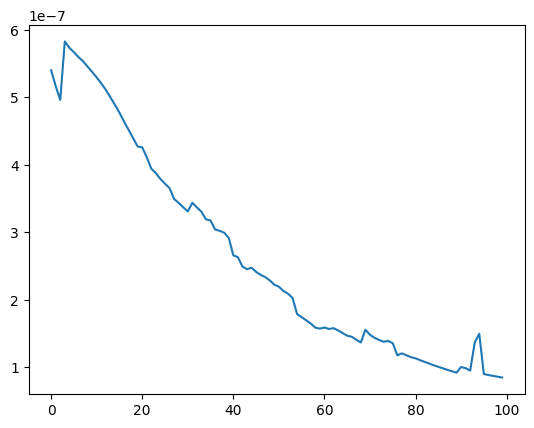

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


loss = np.array([h['loss'] for h in history])

plt.plot(loss)

Text(0.5, 1.0, 'log_tau')

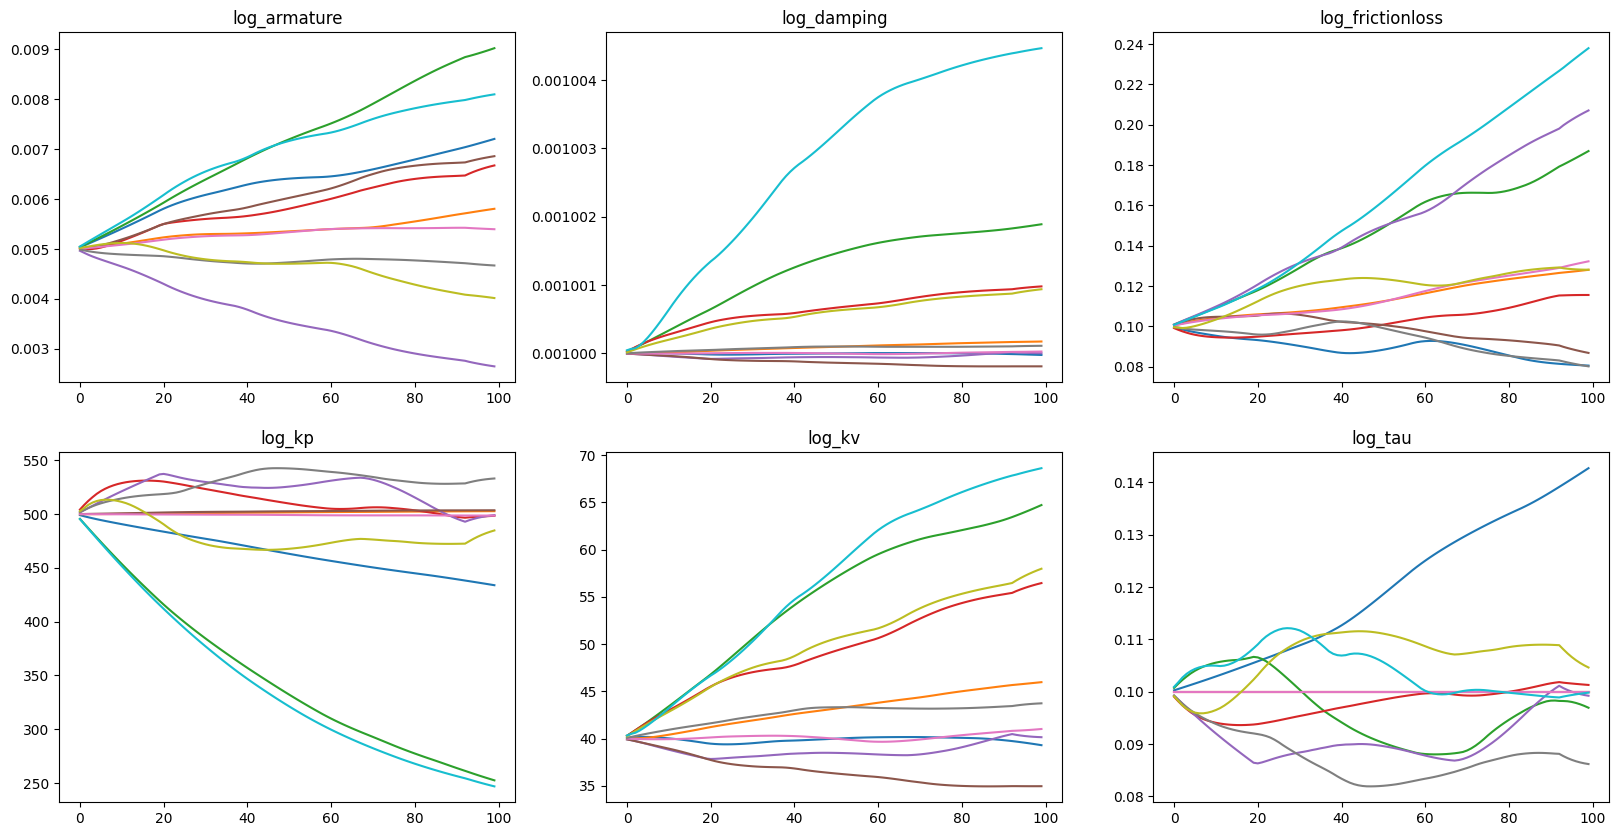

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))
log_armature = np.array([h['params']['log_armature'] for h in history])
log_damping = np.array([h['params']['log_damping'] for h in history])
log_frictionloss = np.array([h['params']['log_frictionloss'] for h in history])
log_kp = np.array([h['params']['log_kp'] for h in history])
log_kv = np.array([h['params']['log_kv'] for h in history])
log_tau = np.array([h['params']['log_tau'] for h in history])

axs[0, 0].plot(np.exp(log_armature))
axs[0, 0].set_title('log_armature')
axs[0, 1].plot(np.exp(log_damping))
axs[0, 1].set_title('log_damping')
axs[0, 2].plot(np.exp(log_frictionloss))
axs[0, 2].set_title('log_frictionloss')
axs[1, 0].plot(np.exp(log_kp))
axs[1, 0].set_title('log_kp')
axs[1, 1].plot(np.exp(log_kv))
axs[1, 1].set_title('log_kv')
axs[1, 2].plot(np.exp(log_tau))
axs[1, 2].set_title('log_tau')

In [ ]:
armature = np.exp(np.array(params['log_armature']))
damping = np.exp(np.array(params['log_damping']))
frictionloss = np.exp(np.array(params['log_frictionloss']))
kp = np.exp(np.array(params['log_kp']))
kv = np.exp(np.array(params['log_kv']))
tau = np.exp(np.array(params['log_tau']))

for item in [armature, damping, frictionloss, kp, kv, tau]:
    print(item.tolist())

[0.007203295826911926, 0.005804134998470545, 0.009019913151860237, 0.006672081537544727, 0.002649093046784401, 0.00685774115845561, 0.005395222455263138, 0.00466896453872323, 0.004017007537186146, 0.008095798082649708]
[0.000999978045001626, 0.0010001749033108354, 0.001001890399493277, 0.0010009811958298087, 0.001000003656372428, 0.0009998115710914135, 0.0010000281035900116, 0.001000111922621727, 0.0010009397519752383, 0.001004466786980629]
[0.08050708472728729, 0.1280188411474228, 0.18693691492080688, 0.11553357541561127, 0.20708420872688293, 0.08679162710905075, 0.1322345733642578, 0.08012007176876068, 0.12807783484458923, 0.237975612282753]
[433.92022705078125, 502.7805480957031, 252.4436492919922, 498.4895324707031, 499.1025085449219, 503.6114501953125, 498.681884765625, 533.1785278320312, 484.8417663574219, 246.83590698242188]
[39.30643081665039, 45.97328567504883, 64.71037292480469, 56.45505905151367, 40.150211334228516, 34.96668243408203, 41.01750946044922, 43.73418426513672, 57